In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import gc
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.base import TransformerMixin, BaseEstimator
from my_functions import *

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression

sns.set_theme()
gc.enable()

In [109]:
class ChunkKNNImputer(BaseEstimator, TransformerMixin):
    def __init__(self, factor):
        self.imputer=KNNImputer()
        self.factor=factor
        self.features=None
    
    def fit(self, X, y=None):
        return self
        
    def fit_transform(self, X, y=None):
        self.features=X.columns
        total_idx=np.array(list(range(X.shape[0])))
        iteration=0
        rng=np.random.default_rng(seed=0)
        rng.shuffle(total_idx)
        result=None
        while(len(total_idx)>iteration*self.factor):
            curr_idx=total_idx[iteration*self.factor : (iteration+1)*self.factor]
            X_curr=X.iloc[curr_idx, :]
            if result is None:
                result=self.imputer.fit_transform(X_curr, y)
            else:
                result=np.concatenate((result, self.imputer.fit_transform(X_curr, y)), axis=0, dtype=float)
            iteration+=1
        return result[total_idx.argsort(), :]

    def transform(self, X, y=None):
        return self.imputer.transform(X, y)    
            
    def get_feature_names_out(self, input_features=None):
        return self.features

            

# Main Data

In [19]:
main_data=pd.read_csv('initial_clean.csv', keep_default_na=False, na_values='')
main_data.drop(['DAYS_BIRTH', 'DAYS_EMPLOYED', 
                'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE', 
                'DAYS_REGISTRATION'], axis=1, inplace=True)
main_data.shape

(307511, 43)

### Dealing with Outliers

In [20]:
'''
contains all outlier marker columns
'''
outlier_frame=main_data.filter(regex='outlier', axis=1).copy()
outlier_frame['SK_ID_CURR']=main_data['SK_ID_CURR']
outlier_frame['TARGET']=main_data['TARGET']
outlier_frame.shape

(307511, 8)

In [21]:
# plot_all_encoded_vs_target(outlier_frame)

In [22]:
outlier_frame.columns

Index(['AMT_CREDIT_outlier', 'AMT_INCOME_TOTAL_outlier', 'AMT_ANNUITY_outlier',
       'AMT_GOODS_PRICE_outlier', 'DAYS_REGISTRATION_outlier',
       'DAYS_EMPLOYED_outlier', 'SK_ID_CURR', 'TARGET'],
      dtype='object')

In [23]:
clean1=main_data.loc[(main_data['AMT_CREDIT_outlier']==0)&
              (main_data['AMT_INCOME_TOTAL_outlier']==0)&
              (main_data['AMT_ANNUITY_outlier']==0)&
              (main_data['AMT_GOODS_PRICE_outlier']==0)&
              (main_data['DAYS_REGISTRATION_outlier']==0)&
              (main_data['DAYS_EMPLOYED_outlier']==0), :].copy()
clean1.drop(labels=outlier_frame.columns.difference(['SK_ID_CURR', 'TARGET']), axis=1, inplace=True)
clean1.loc[clean1['NAME_FAMILY_STATUS'].isnull(), 'NAME_FAMILY_STATUS']=clean1['NAME_FAMILY_STATUS'].mode().values[0]
clean1.shape

(306295, 37)

### Scaling

In [24]:
clean1.columns.sort_values()

Index(['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_GOODS_PRICE', 'AMT_INCOME_TOTAL',
       'CODE_GENDER', 'EMERGENCYSTATE_MODE', 'EXT_SOURCE_1', 'EXT_SOURCE_2',
       'EXT_SOURCE_3', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_6', 'FLAG_EMP_PHONE',
       'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'FLAG_PHONE', 'FLAG_WORK_PHONE',
       'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'LIVE_CITY_NOT_WORK_CITY',
       'NAME_CONTRACT_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
       'NAME_HOUSING_TYPE', 'NAME_INCOME_TYPE', 'NAME_TYPE_SUITE',
       'OCCUPATION_TYPE', 'ORGANIZATION_TYPE', 'REG_CITY_NOT_LIVE_CITY',
       'REG_CITY_NOT_WORK_CITY', 'SK_ID_CURR', 'TARGET', 'WALLSMATERIAL_MODE',
       'YEARS_BIRTH', 'YEARS_EMPLOYED', 'YEARS_ID_PUBLISH',
       'YEARS_LAST_PHONE_CHANGE', 'YEARS_REGISTRATION'],
      dtype='object')

In [25]:
ct=ColumnTransformer(transformers=[('numerical', StandardScaler(), ['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_GOODS_PRICE',
                                                                    'YEARS_BIRTH', 'YEARS_ID_PUBLISH', 'YEARS_REGISTRATION', 
                                                                    'YEARS_EMPLOYED', 'YEARS_LAST_PHONE_CHANGE'])],
                     remainder='passthrough')
clean2=pd.DataFrame(ct.fit_transform(clean1))
clean2.columns=ct.get_feature_names_out()
clean2.rename(columns=lambda x: x[11:], inplace=True)
clean2.shape

(306295, 37)

### Imputing Null Values and Encoding Categorical Variables

In [26]:
clean2.columns

Index(['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_GOODS_PRICE',
       'YEARS_BIRTH', 'YEARS_ID_PUBLISH', 'YEARS_REGISTRATION',
       'YEARS_EMPLOYED', 'YEARS_LAST_PHONE_CHANGE', 'EXT_SOURCE_1',
       'EXT_SOURCE_2', 'EXT_SOURCE_3', 'TARGET', 'SK_ID_CURR', 'CODE_GENDER',
       'EMERGENCYSTATE_MODE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'NAME_CONTRACT_TYPE',
       'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
       'NAME_INCOME_TYPE', 'NAME_TYPE_SUITE', 'OCCUPATION_TYPE',
       'ORGANIZATION_TYPE', 'WALLSMATERIAL_MODE', 'FLAG_DOCUMENT_3',
       'FLAG_DOCUMENT_6', 'FLAG_EMP_PHONE', 'FLAG_PHONE', 'FLAG_WORK_PHONE',
       'LIVE_CITY_NOT_WORK_CITY', 'REG_CITY_NOT_LIVE_CITY',
       'REG_CITY_NOT_WORK_CITY'],
      dtype='object')

#### This Cell will take a long time upto (3.5 minutes)

In [28]:
ct2=ColumnTransformer(transformers=[('numerical', ChunkKNNImputer(factor=10000), ['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_INCOME_TOTAL', 
                                                                                     'AMT_GOODS_PRICE', 'YEARS_BIRTH', 'YEARS_ID_PUBLISH', 
                                                                                     'YEARS_REGISTRATION', 'YEARS_EMPLOYED', 'YEARS_LAST_PHONE_CHANGE', 
                                                                                     'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']),
                                    
                                    ('encodings', OneHotEncoder(sparse_output=False), ['CODE_GENDER', 'EMERGENCYSTATE_MODE', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
                                                                    'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'NAME_CONTRACT_TYPE',
                                                                    'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE',
                                                                    'NAME_INCOME_TYPE', 'NAME_TYPE_SUITE', 'OCCUPATION_TYPE',
                                                                    'ORGANIZATION_TYPE', 'WALLSMATERIAL_MODE'])],
                      remainder='passthrough', n_jobs=-1)


clean3=pd.DataFrame(ct2.fit_transform(clean2))
clean3.columns=ct2.get_feature_names_out()
clean3.rename(columns=lambda x: x[11:], inplace=True)
clean3=clean3.astype(dtype=float)
clean3.shape

(306295, 159)

In [29]:
clean3.columns.values

array(['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_GOODS_PRICE',
       'YEARS_BIRTH', 'YEARS_ID_PUBLISH', 'YEARS_REGISTRATION',
       'YEARS_EMPLOYED', 'YEARS_LAST_PHONE_CHANGE', 'EXT_SOURCE_1',
       'EXT_SOURCE_2', 'EXT_SOURCE_3', 'CODE_GENDER_F', 'CODE_GENDER_M',
       'EMERGENCYSTATE_MODE_NULL', 'EMERGENCYSTATE_MODE_No',
       'EMERGENCYSTATE_MODE_Yes', 'FLAG_OWN_CAR_N', 'FLAG_OWN_CAR_Y',
       'FLAG_OWN_REALTY_N', 'FLAG_OWN_REALTY_Y',
       'FONDKAPREMONT_MODE_NULL', 'FONDKAPREMONT_MODE_not specified',
       'FONDKAPREMONT_MODE_org spec account',
       'FONDKAPREMONT_MODE_reg oper account',
       'FONDKAPREMONT_MODE_reg oper spec account', 'HOUSETYPE_MODE_NULL',
       'HOUSETYPE_MODE_block of flats', 'HOUSETYPE_MODE_specific housing',
       'HOUSETYPE_MODE_terraced house', 'NAME_CONTRACT_TYPE_Cash loans',
       'NAME_CONTRACT_TYPE_Revolving loans',
       'NAME_EDUCATION_TYPE_Academic degree',
       'NAME_EDUCATION_TYPE_Higher education',
       'NAME_EDUCA

#### further cleaning (dropping based on correlation)

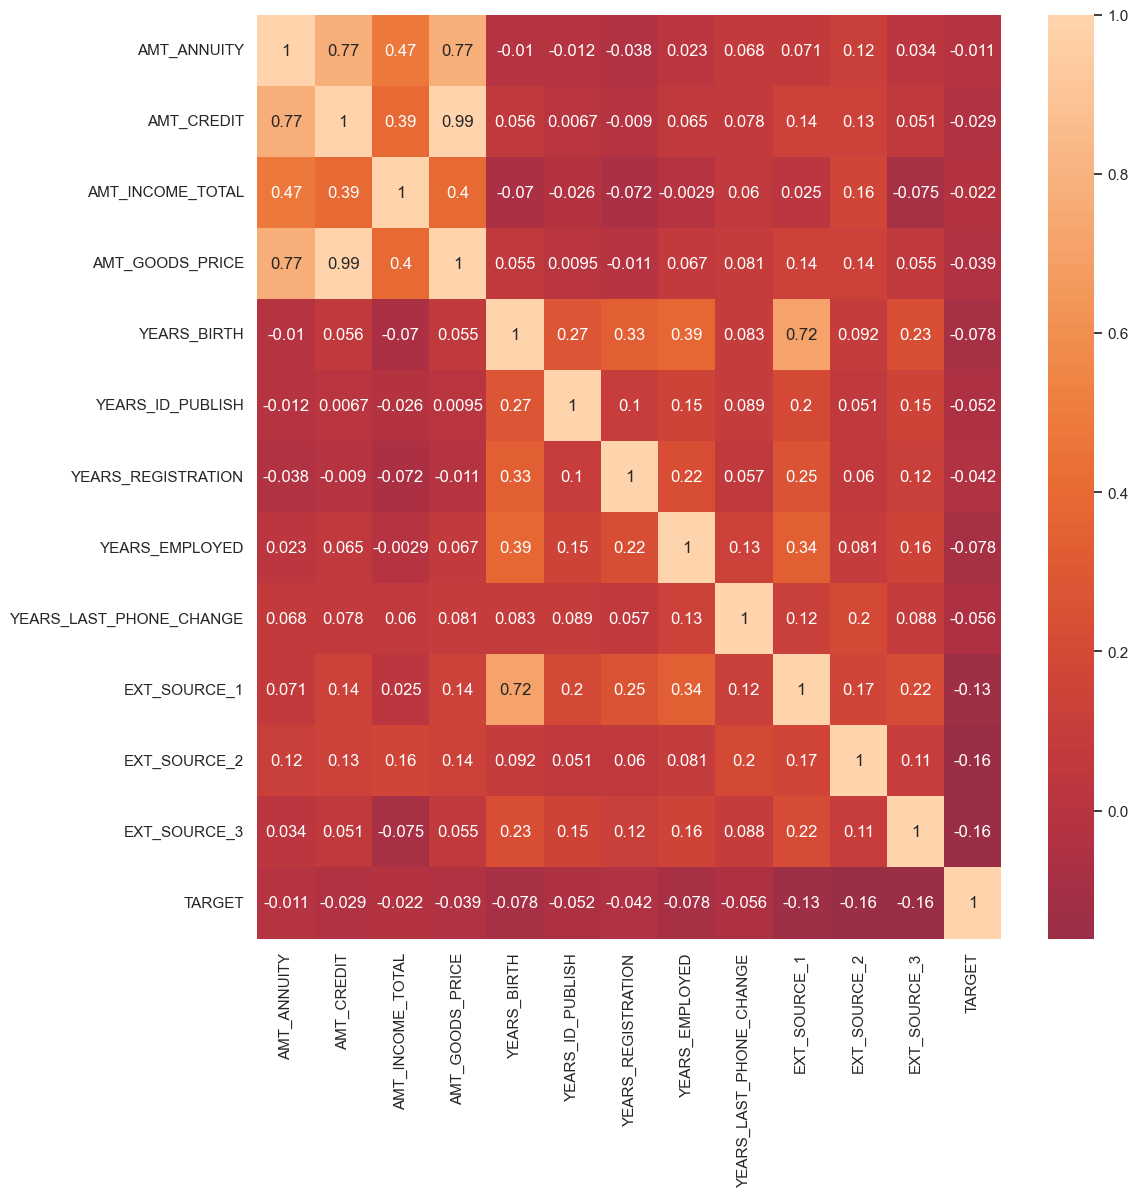

In [30]:
ax=sns.heatmap(clean3[['AMT_ANNUITY', 'AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_GOODS_PRICE',
       'YEARS_BIRTH', 'YEARS_ID_PUBLISH', 'YEARS_REGISTRATION',
       'YEARS_EMPLOYED', 'YEARS_LAST_PHONE_CHANGE', 'EXT_SOURCE_1',
       'EXT_SOURCE_2', 'EXT_SOURCE_3', 'TARGET']].corr(), annot=True, center=-1)
ax.get_figure().set_size_inches(w=12, h=12)


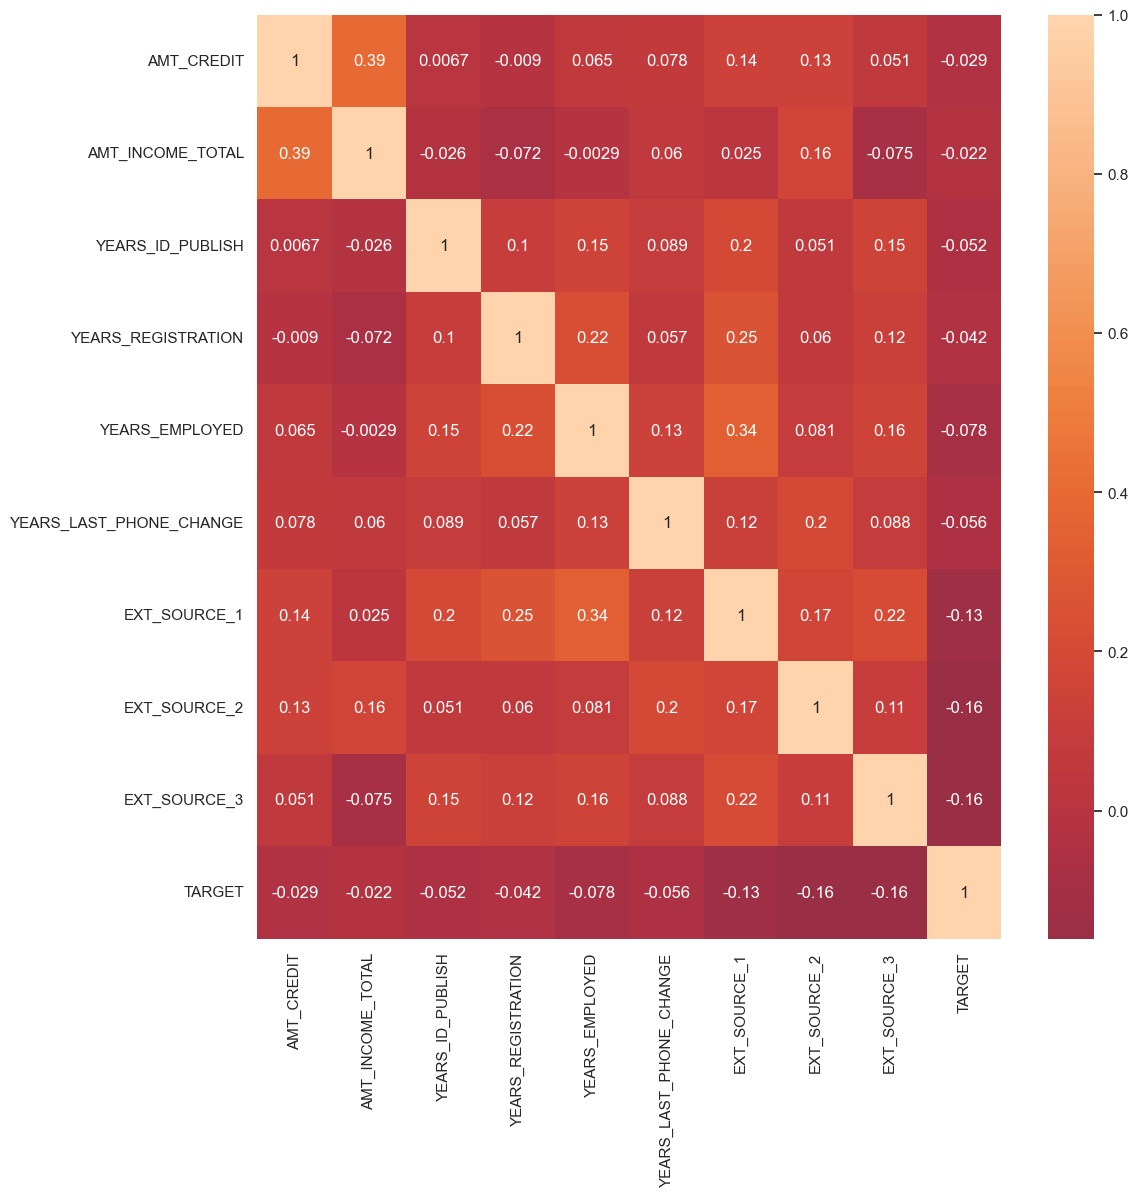

In [31]:
clean3.drop(labels=['AMT_ANNUITY', 'AMT_GOODS_PRICE', 'YEARS_BIRTH'], axis=1, inplace=True)
ax=sns.heatmap(clean3[['AMT_CREDIT', 'AMT_INCOME_TOTAL', 'YEARS_ID_PUBLISH', 'YEARS_REGISTRATION',
       'YEARS_EMPLOYED', 'YEARS_LAST_PHONE_CHANGE', 'EXT_SOURCE_1',
       'EXT_SOURCE_2', 'EXT_SOURCE_3', 'TARGET']].corr(), annot=True, center=-1)
ax.get_figure().set_size_inches(w=12, h=12)


Uncomment This Code for creating the file

In [32]:
# clean3.to_csv('final_clean_main.csv', index=False)

# Bureau Data

freeing memory

In [33]:
del main_data
del clean1
del clean2
del clean3
del outlier_frame
gc.collect()

47273

In [3]:
bureau_data=pd.read_csv('initial_clean_bureau.csv', keep_default_na=False, na_values='')
bureau_data.shape

(263491, 19)

In [4]:
bureau_data.columns.sort_values()

Index(['DAYS_CREDIT_ENDDATE_median_outlier', 'DAYS_CREDIT_ENDDATE_min_outlier',
       'DAYS_CREDIT_UPDATE_median_outlier', 'DAYS_CREDIT_UPDATE_min_outlier',
       'DAYS_ENDDATE_FACT_min_outlier', 'SK_ID_CURR', 'STATUS_<31DPD_max',
       'STATUS_ACTIVE', 'STATUS_ACTIVE_PCT', 'TARGET',
       'YEARS_CREDIT_ENDDATE_median', 'YEARS_CREDIT_ENDDATE_min',
       'YEARS_CREDIT_UPDATE_median', 'YEARS_CREDIT_UPDATE_min',
       'YEARS_CREDIT_max', 'YEARS_CREDIT_median', 'YEARS_CREDIT_min',
       'YEARS_ENDDATE_FACT_median', 'YEARS_ENDDATE_FACT_min'],
      dtype='object')

### Dealing with Outliers

In [5]:
'''
contains all outlier marker columns
'''
outlier_frame=bureau_data.filter(regex='outlier', axis=1).copy()
outlier_frame['SK_ID_CURR']=bureau_data['SK_ID_CURR']
outlier_frame['TARGET']=bureau_data['TARGET']
outlier_frame.shape

(263491, 7)

In [30]:
# plot_all_encoded_vs_target(outlier_frame)

In [6]:
outlier_frame.columns

Index(['DAYS_CREDIT_ENDDATE_min_outlier', 'DAYS_CREDIT_ENDDATE_median_outlier',
       'DAYS_ENDDATE_FACT_min_outlier', 'DAYS_CREDIT_UPDATE_min_outlier',
       'DAYS_CREDIT_UPDATE_median_outlier', 'SK_ID_CURR', 'TARGET'],
      dtype='object')

In [7]:
clean1=bureau_data.loc[(bureau_data['DAYS_CREDIT_ENDDATE_min_outlier']==0)&
              (bureau_data['DAYS_CREDIT_ENDDATE_median_outlier']==0)&
              (bureau_data['DAYS_ENDDATE_FACT_min_outlier']==0)&
              (bureau_data['DAYS_CREDIT_UPDATE_min_outlier']==0)&
              (bureau_data['DAYS_CREDIT_UPDATE_median_outlier']==0), :].copy()
clean1.drop(labels=outlier_frame.columns.difference(['SK_ID_CURR', 'TARGET']), axis=1, inplace=True)
bureau_data.drop(labels=outlier_frame.columns.difference(['SK_ID_CURR', 'TARGET']), axis=1, inplace=True)
clean1.shape

(251667, 14)

### Scaling

In [8]:
clean1.head()

,STATUS_<31DPD_max,SK_ID_CURR,TARGET,YEARS_CREDIT_min,YEARS_CREDIT_max,YEARS_CREDIT_median,YEARS_CREDIT_ENDDATE_min,YEARS_CREDIT_ENDDATE_median,YEARS_ENDDATE_FACT_min,YEARS_ENDDATE_FACT_median,YEARS_CREDIT_UPDATE_min,YEARS_CREDIT_UPDATE_median,STATUS_ACTIVE,STATUS_ACTIVE_PCT
0,6.0,100002,1,3.936986,0.282192,2.856164,-2.936986,-1.163014,3.246575,2.572603,3.246575,1.102740,2.0,25.000000
1,0.0,100003,0,7.084932,1.660274,3.302740,-6.668493,-1.315068,5.838356,1.701370,5.838356,1.493151,1.0,25.000000
2,0.0,100004,0,3.632877,1.117808,2.375342,-1.630137,-1.338356,1.871233,1.458904,1.868493,1.457534,0.0,0.000000
3,0.0,100007,0,3.147945,3.147945,3.147945,-2.145205,-2.145205,2.145205,2.145205,2.145205,2.145205,0.0,0.000000
4,0.0,100008,0,3.005479,0.213699,3.005479,-2.336986,-2.169863,2.816438,2.490411,2.813699,2.164384,1.0,33.333333


In [9]:
clean1.columns.sort_values()

Index(['SK_ID_CURR', 'STATUS_<31DPD_max', 'STATUS_ACTIVE', 'STATUS_ACTIVE_PCT',
       'TARGET', 'YEARS_CREDIT_ENDDATE_median', 'YEARS_CREDIT_ENDDATE_min',
       'YEARS_CREDIT_UPDATE_median', 'YEARS_CREDIT_UPDATE_min',
       'YEARS_CREDIT_max', 'YEARS_CREDIT_median', 'YEARS_CREDIT_min',
       'YEARS_ENDDATE_FACT_median', 'YEARS_ENDDATE_FACT_min'],
      dtype='object')

In [10]:
ct=ColumnTransformer(transformers=[('numerical', StandardScaler(), ['STATUS_ACTIVE', 'STATUS_ACTIVE_PCT',
                                                                    'YEARS_CREDIT_ENDDATE_median', 'YEARS_CREDIT_ENDDATE_min',
                                                                    'YEARS_CREDIT_UPDATE_median', 'YEARS_CREDIT_UPDATE_min',
                                                                    'YEARS_CREDIT_max', 'YEARS_CREDIT_median', 'YEARS_CREDIT_min',
                                                                    'YEARS_ENDDATE_FACT_median', 'YEARS_ENDDATE_FACT_min'])],
                     remainder='passthrough')
ct.fit(clean1)
clean2=pd.DataFrame(ct.transform(bureau_data))
clean2.columns=ct.get_feature_names_out()
clean2.rename(columns=lambda x: x[11:], inplace=True)
clean2.shape

(263491, 14)

### Imputing Null Values

In [11]:
clean2.columns.sort_values()

Index(['SK_ID_CURR', 'STATUS_<31DPD_max', 'STATUS_ACTIVE', 'STATUS_ACTIVE_PCT',
       'TARGET', 'YEARS_CREDIT_ENDDATE_median', 'YEARS_CREDIT_ENDDATE_min',
       'YEARS_CREDIT_UPDATE_median', 'YEARS_CREDIT_UPDATE_min',
       'YEARS_CREDIT_max', 'YEARS_CREDIT_median', 'YEARS_CREDIT_min',
       'YEARS_ENDDATE_FACT_median', 'YEARS_ENDDATE_FACT_min'],
      dtype='object')

#### This Cell will take a long time upto (1 minute)

In [12]:
ct2=ColumnTransformer(transformers=[('numerical', ChunkKNNImputer(factor=10000), ['STATUS_<31DPD_max', 'STATUS_ACTIVE', 'STATUS_ACTIVE_PCT',
                                                                                    'YEARS_CREDIT_ENDDATE_median', 'YEARS_CREDIT_ENDDATE_min',
                                                                                    'YEARS_CREDIT_UPDATE_median', 'YEARS_CREDIT_UPDATE_min',
                                                                                    'YEARS_CREDIT_max', 'YEARS_CREDIT_median', 'YEARS_CREDIT_min',
                                                                                    'YEARS_ENDDATE_FACT_median', 'YEARS_ENDDATE_FACT_min'])],
                      remainder='passthrough', n_jobs=-1)


clean3=pd.DataFrame(ct2.fit_transform(clean2))
clean3.columns=ct2.get_feature_names_out()
clean3.rename(columns=lambda x: x[11:], inplace=True)
clean3=clean3.astype(dtype=float)
clean3.shape

(263491, 14)

In [13]:
clean3.columns.sort_values()

Index(['SK_ID_CURR', 'STATUS_<31DPD_max', 'STATUS_ACTIVE', 'STATUS_ACTIVE_PCT',
       'TARGET', 'YEARS_CREDIT_ENDDATE_median', 'YEARS_CREDIT_ENDDATE_min',
       'YEARS_CREDIT_UPDATE_median', 'YEARS_CREDIT_UPDATE_min',
       'YEARS_CREDIT_max', 'YEARS_CREDIT_median', 'YEARS_CREDIT_min',
       'YEARS_ENDDATE_FACT_median', 'YEARS_ENDDATE_FACT_min'],
      dtype='object')

#### further cleaning (dropping based on correlation)

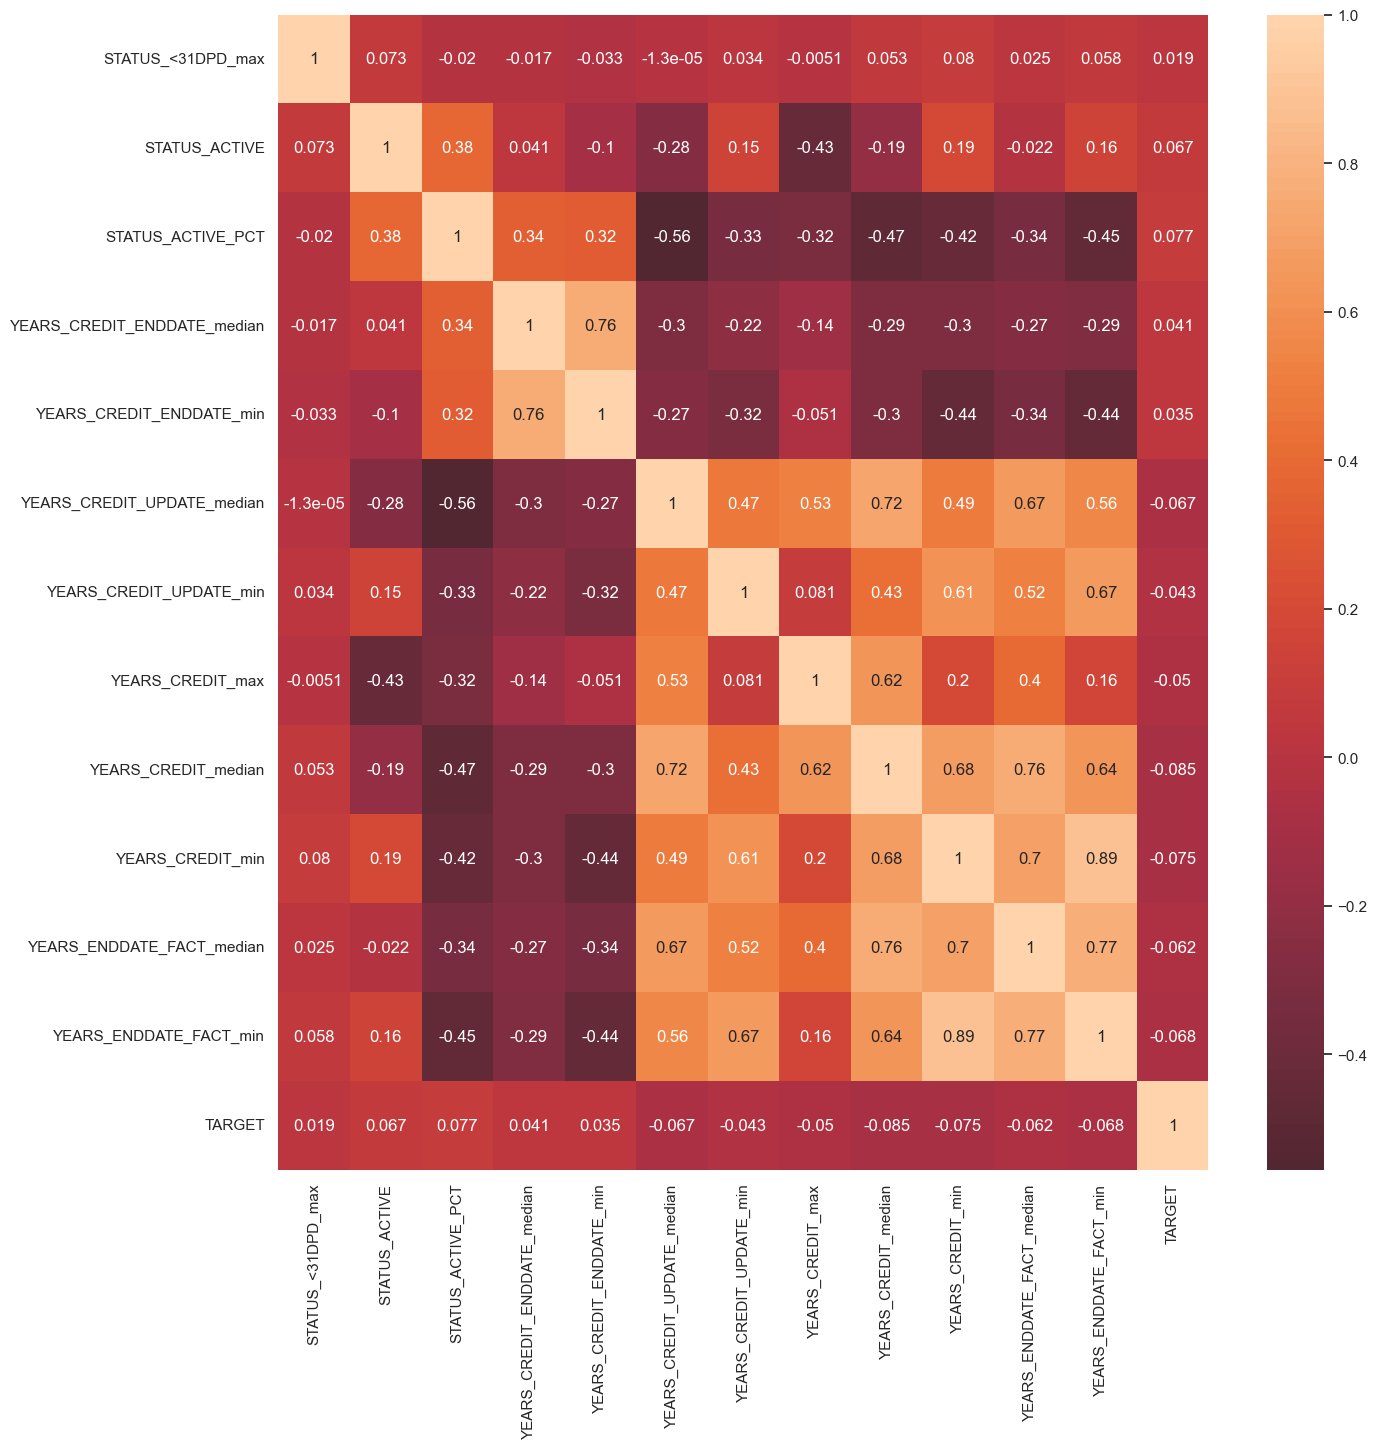

In [15]:
ax=sns.heatmap(clean3.drop(labels=['SK_ID_CURR'], axis=1).corr(), annot=True, center=-1)
ax.get_figure().set_size_inches(w=15, h=15)


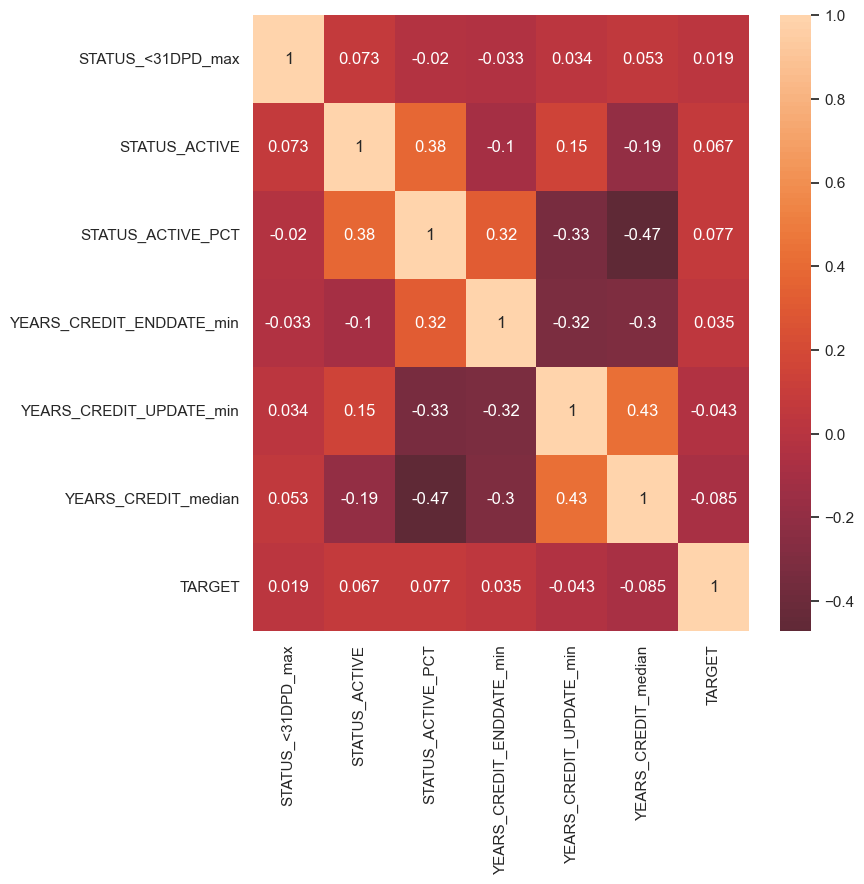

In [19]:
clean3.drop(labels=['YEARS_CREDIT_ENDDATE_median', 'YEARS_CREDIT_UPDATE_median', 
                           'YEARS_CREDIT_min', 'YEARS_CREDIT_max', 'YEARS_ENDDATE_FACT_median',
                           'YEARS_ENDDATE_FACT_min'], axis=1, inplace=True)
ax=sns.heatmap(clean3.drop(labels='SK_ID_CURR', axis=1).corr(), annot=True, center=-1)
ax.get_figure().set_size_inches(w=8, h=8)


Uncomment This Code for creating the file

In [21]:
# clean3.to_csv('final_clean_bureau.csv', index=False)

# POS Data

freeing memory

In [22]:
del bureau_data
del clean1
del clean2
del clean3
del outlier_frame
gc.collect()

45323

In [24]:
pos_data=pd.read_csv('initial_clean_pos.csv', keep_default_na=False, na_values='')
pos_data.shape

(289444, 10)

In [25]:
pos_data.columns.sort_values()

Index(['ACTUAL_INSTALMENTS_sum', 'ACTUAL_INSTALMENTS_sum_outlier',
       'CONTRACT_STATUS_Active_PCT', 'INSTALMENT_REDUCTION_PCT_max',
       'MONTHS_BALANCE_median', 'MONTHS_BALANCE_min', 'RECORD_count_sum',
       'RECORD_count_sum_outlier', 'SK_ID_CURR', 'TARGET'],
      dtype='object')

### Dealing with Outliers

In [26]:
'''
contains all outlier marker columns
'''
outlier_frame=pos_data.filter(regex='outlier', axis=1).copy()
outlier_frame['SK_ID_CURR']=pos_data['SK_ID_CURR']
outlier_frame['TARGET']=pos_data['TARGET']
outlier_frame.shape

(289444, 4)

In [52]:
# plot_all_encoded_vs_target(outlier_frame)

In [28]:
outlier_frame.columns

Index(['ACTUAL_INSTALMENTS_sum_outlier', 'RECORD_count_sum_outlier',
       'SK_ID_CURR', 'TARGET'],
      dtype='object')

In [30]:
clean1=pos_data.loc[(pos_data['ACTUAL_INSTALMENTS_sum_outlier']==0)&
                       (pos_data['RECORD_count_sum_outlier']==0), :].copy()
clean1.drop(labels=outlier_frame.columns.difference(['SK_ID_CURR', 'TARGET']), axis=1, inplace=True)
pos_data.drop(labels=outlier_frame.columns.difference(['SK_ID_CURR', 'TARGET']), axis=1, inplace=True)
clean1.shape

(289342, 8)

### Scaling

In [31]:
clean1.head()

,SK_ID_CURR,TARGET,ACTUAL_INSTALMENTS_sum,RECORD_count_sum,INSTALMENT_REDUCTION_PCT_max,MONTHS_BALANCE_min,MONTHS_BALANCE_median,CONTRACT_STATUS_Active_PCT
0,100002,1,24.0,19,0.000000,1,1.0,100.000000
1,100003,0,25.0,28,41.666667,66,21.0,33.333333
2,100004,0,3.0,4,25.000000,24,24.0,0.000000
3,100006,0,18.0,21,97.916667,13,4.0,33.333333
4,100007,0,75.0,66,5.555556,68,24.0,40.000000


In [32]:
clean1.columns.sort_values()

Index(['ACTUAL_INSTALMENTS_sum', 'CONTRACT_STATUS_Active_PCT',
       'INSTALMENT_REDUCTION_PCT_max', 'MONTHS_BALANCE_median',
       'MONTHS_BALANCE_min', 'RECORD_count_sum', 'SK_ID_CURR', 'TARGET'],
      dtype='object')

In [34]:
ct=ColumnTransformer(transformers=[('numerical', StandardScaler(), ['ACTUAL_INSTALMENTS_sum', 'CONTRACT_STATUS_Active_PCT',
                                                                    'INSTALMENT_REDUCTION_PCT_max', 'MONTHS_BALANCE_median',
                                                                    'MONTHS_BALANCE_min', 'RECORD_count_sum'])],
                     remainder='passthrough')
ct.fit(clean1)
clean2=pd.DataFrame(ct.transform(pos_data))
clean2.columns=ct.get_feature_names_out()
clean2.rename(columns=lambda x: x[11:], inplace=True)
clean2.shape

(289444, 8)

### Imputing Null Values

In [35]:
clean2.columns.sort_values()

Index(['ACTUAL_INSTALMENTS_sum', 'CONTRACT_STATUS_Active_PCT',
       'INSTALMENT_REDUCTION_PCT_max', 'MONTHS_BALANCE_median',
       'MONTHS_BALANCE_min', 'RECORD_count_sum', 'SK_ID_CURR', 'TARGET'],
      dtype='object')

In [37]:
ct2=ColumnTransformer(transformers=[('numerical', ChunkKNNImputer(factor=10000), ['ACTUAL_INSTALMENTS_sum', 'CONTRACT_STATUS_Active_PCT',
                                                                                'INSTALMENT_REDUCTION_PCT_max', 'MONTHS_BALANCE_median',
                                                                                'MONTHS_BALANCE_min', 'RECORD_count_sum'])],
                      remainder='passthrough', n_jobs=-1)


clean3=pd.DataFrame(ct2.fit_transform(clean2))
clean3.columns=ct2.get_feature_names_out()
clean3.rename(columns=lambda x: x[11:], inplace=True)
clean3=clean3.astype(dtype=float)
clean3.shape

(289444, 8)

In [38]:
clean3.columns.sort_values()

Index(['ACTUAL_INSTALMENTS_sum', 'CONTRACT_STATUS_Active_PCT',
       'INSTALMENT_REDUCTION_PCT_max', 'MONTHS_BALANCE_median',
       'MONTHS_BALANCE_min', 'RECORD_count_sum', 'SK_ID_CURR', 'TARGET'],
      dtype='object')

#### further cleaning (dropping based on correlation)

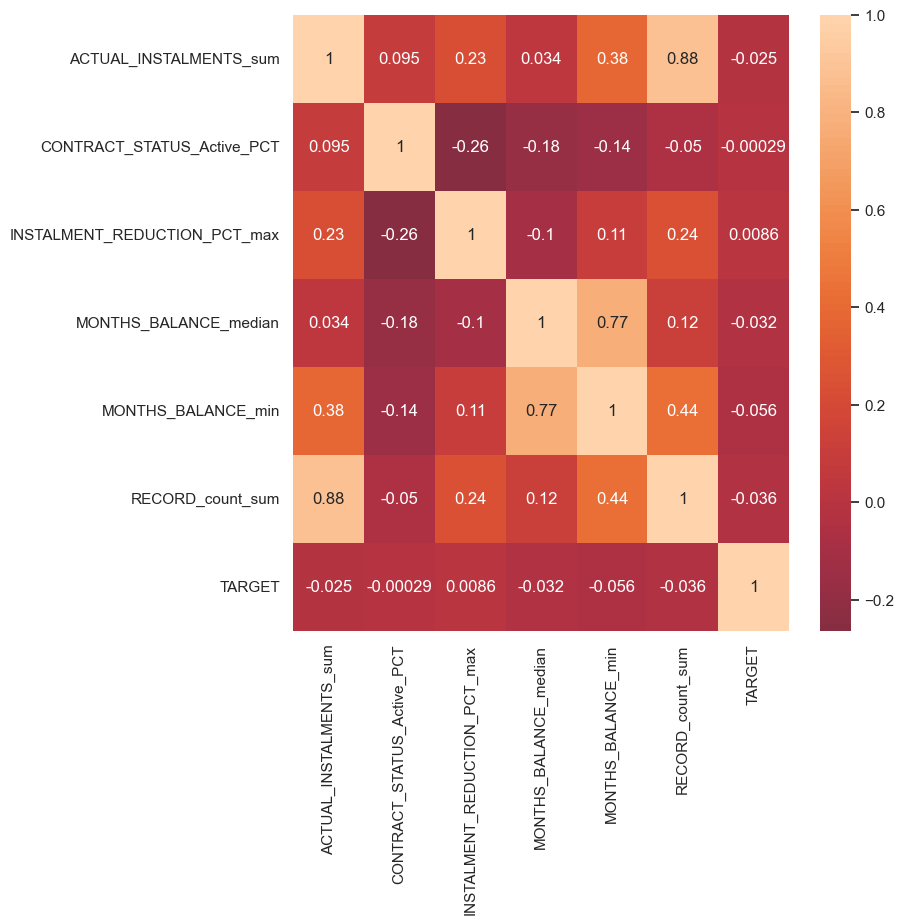

In [40]:
ax=sns.heatmap(clean3.drop(labels=['SK_ID_CURR'], axis=1).corr(), annot=True, center=-1)
ax.get_figure().set_size_inches(w=8, h=8)


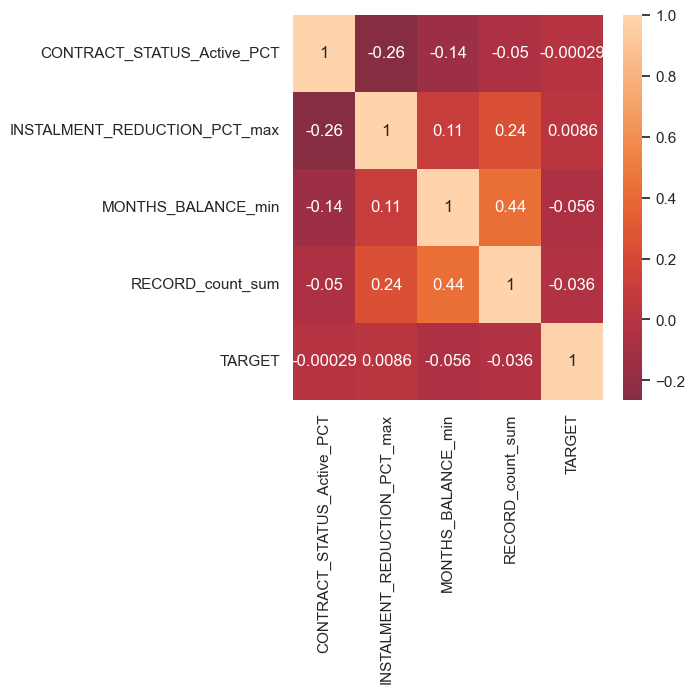

In [43]:
clean3.drop(labels=['ACTUAL_INSTALMENTS_sum', 'MONTHS_BALANCE_median'], axis=1, inplace=True)
ax=sns.heatmap(clean3.drop(labels='SK_ID_CURR', axis=1).corr(), annot=True, center=-1)
ax.get_figure().set_size_inches(w=5, h=5)

Uncomment This Code for creating the file

In [44]:
# clean3.to_csv('final_clean_pos.csv', index=False)

# Instalments

freeing memory

In [ ]:
del pos_data
del clean1
del clean2
del clean3
del outlier_frame
gc.collect()

In [47]:
ins_data=pd.read_csv('initial_clean_instalments.csv', keep_default_na=False, na_values='')
ins_data.shape

(291643, 10)

In [48]:
ins_data.columns.sort_values()

Index(['AMT_INSTALMENT_median', 'AMT_INSTALMENT_median_outlier',
       'AMT_PAYMENT_DIFFERENCE_sum', 'AMT_PAYMENT_DIFFERENCE_sum_outlier',
       'DAYS_INSTALMENT_min', 'DAYS_PAYMENT_DIFFERENCE_median',
       'DAYS_PAYMENT_DIFFERENCE_sum', 'LATE_PAYMENT_PCT_max', 'SK_ID_CURR',
       'TARGET'],
      dtype='object')

### Dealing with Outliers

In [49]:
'''
contains all outlier marker columns
'''
outlier_frame=ins_data.filter(regex='outlier', axis=1).copy()
outlier_frame['SK_ID_CURR']=ins_data['SK_ID_CURR']
outlier_frame['TARGET']=ins_data['TARGET']
outlier_frame.shape

(291643, 4)

In [53]:
# plot_all_encoded_vs_target(outlier_frame)

In [54]:
outlier_frame.columns

Index(['AMT_INSTALMENT_median_outlier', 'AMT_PAYMENT_DIFFERENCE_sum_outlier',
       'SK_ID_CURR', 'TARGET'],
      dtype='object')

In [55]:
clean1=ins_data.loc[(ins_data['AMT_INSTALMENT_median_outlier']==0)&
              (ins_data['AMT_PAYMENT_DIFFERENCE_sum_outlier']==0), :].copy()
clean1.drop(labels=outlier_frame.columns.difference(['SK_ID_CURR', 'TARGET']), axis=1, inplace=True)
ins_data.drop(labels=outlier_frame.columns.difference(['SK_ID_CURR', 'TARGET']), axis=1, inplace=True)
clean1.shape

(291028, 8)

### Scaling

In [56]:
clean1.head()

,SK_ID_CURR,TARGET,AMT_INSTALMENT_median,AMT_PAYMENT_DIFFERENCE_sum,DAYS_INSTALMENT_min,DAYS_PAYMENT_DIFFERENCE_median,DAYS_PAYMENT_DIFFERENCE_sum,LATE_PAYMENT_PCT_max
0,100002,1,9251.775,0.000,-565.0,-19.0,-388.0,0.0
1,100003,0,64275.615,0.000,-2310.0,-6.0,-179.0,0.0
2,100004,0,5357.250,0.000,-784.0,-9.0,-23.0,0.0
3,100006,0,29027.520,0.000,-545.0,-6.0,-310.0,0.0
4,100007,0,16037.640,29857.365,-2326.0,-2.0,-240.0,100.0


In [57]:
clean1.columns.sort_values()

Index(['AMT_INSTALMENT_median', 'AMT_PAYMENT_DIFFERENCE_sum',
       'DAYS_INSTALMENT_min', 'DAYS_PAYMENT_DIFFERENCE_median',
       'DAYS_PAYMENT_DIFFERENCE_sum', 'LATE_PAYMENT_PCT_max', 'SK_ID_CURR',
       'TARGET'],
      dtype='object')

In [59]:
ct=ColumnTransformer(transformers=[('numerical', StandardScaler(),['AMT_INSTALMENT_median', 'AMT_PAYMENT_DIFFERENCE_sum',
                                                                    'DAYS_INSTALMENT_min', 'DAYS_PAYMENT_DIFFERENCE_median',
                                                                    'DAYS_PAYMENT_DIFFERENCE_sum', 'LATE_PAYMENT_PCT_max'])],
                     remainder='passthrough')
ct.fit(clean1)
clean2=pd.DataFrame(ct.transform(clean1))
clean2.columns=ct.get_feature_names_out()
clean2.rename(columns=lambda x: x[11:], inplace=True)
clean2.shape

(291028, 8)

### Imputing Null Values

In [60]:
clean2.columns.sort_values()

Index(['AMT_INSTALMENT_median', 'AMT_PAYMENT_DIFFERENCE_sum',
       'DAYS_INSTALMENT_min', 'DAYS_PAYMENT_DIFFERENCE_median',
       'DAYS_PAYMENT_DIFFERENCE_sum', 'LATE_PAYMENT_PCT_max', 'SK_ID_CURR',
       'TARGET'],
      dtype='object')

In [61]:
ct2=ColumnTransformer(transformers=[('numerical', ChunkKNNImputer(factor=10000), ['AMT_INSTALMENT_median', 'AMT_PAYMENT_DIFFERENCE_sum',
                                                                                    'DAYS_INSTALMENT_min', 'DAYS_PAYMENT_DIFFERENCE_median',
                                                                                    'DAYS_PAYMENT_DIFFERENCE_sum', 'LATE_PAYMENT_PCT_max'])],
                      remainder='passthrough', n_jobs=-1)


clean3=pd.DataFrame(ct2.fit_transform(clean2))
clean3.columns=ct2.get_feature_names_out()
clean3.rename(columns=lambda x: x[11:], inplace=True)
clean3=clean3.astype(dtype=float)
clean3.shape

(291028, 8)

In [62]:
clean3.columns.sort_values()

Index(['AMT_INSTALMENT_median', 'AMT_PAYMENT_DIFFERENCE_sum',
       'DAYS_INSTALMENT_min', 'DAYS_PAYMENT_DIFFERENCE_median',
       'DAYS_PAYMENT_DIFFERENCE_sum', 'LATE_PAYMENT_PCT_max', 'SK_ID_CURR',
       'TARGET'],
      dtype='object')

#### further cleaning (dropping based on correlation)

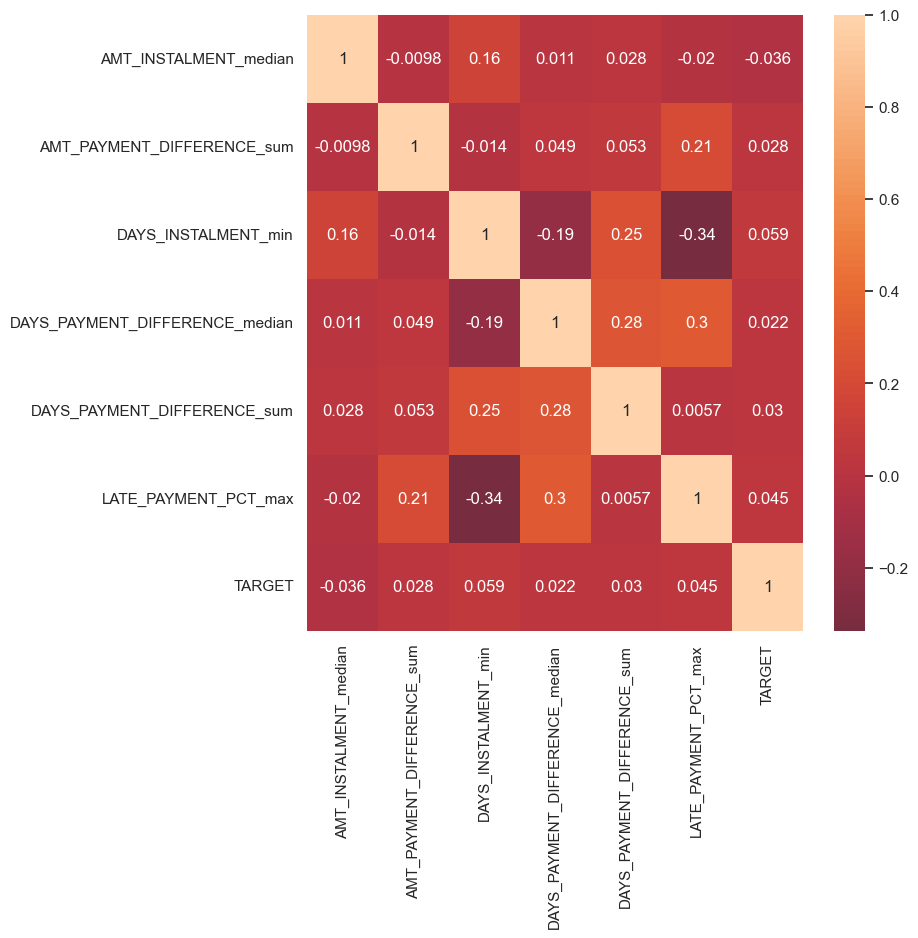

In [64]:
ax=sns.heatmap(clean3.drop(labels=['SK_ID_CURR'], axis=1).corr(), annot=True, center=-1)
ax.get_figure().set_size_inches(w=8, h=8)

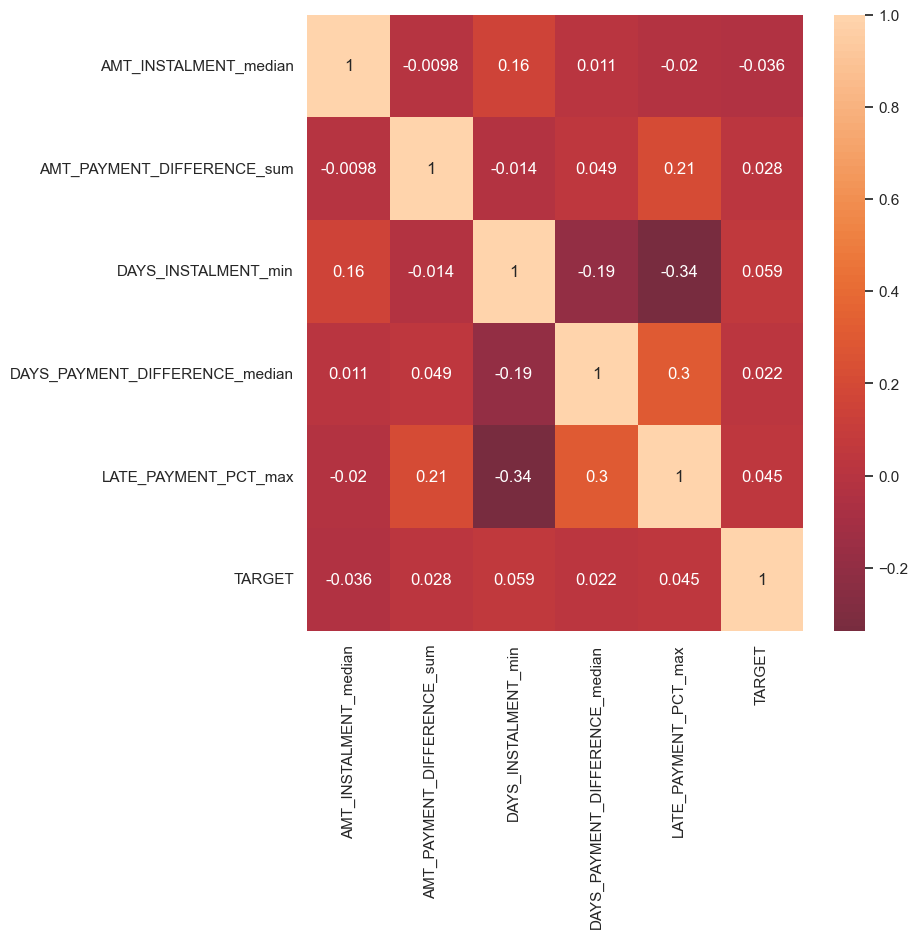

In [65]:
clean3.drop(labels=['DAYS_PAYMENT_DIFFERENCE_sum'], axis=1, inplace=True)
ax=sns.heatmap(clean3.drop(labels='SK_ID_CURR', axis=1).corr(), annot=True, center=-1)
ax.get_figure().set_size_inches(w=8, h=8)


Uncomment This Code for creating the file

In [66]:
# clean3.to_csv('final_clean_instalments.csv', index=False)

# Card Data

freeing memory

In [67]:
del ins_data
del clean1
del clean2
del clean3
del outlier_frame
gc.collect()

25062

In [68]:
card_data=pd.read_csv('initial_clean_card.csv', keep_default_na=False, na_values='')
card_data.shape

(86905, 9)

In [69]:
card_data.columns.sort_values()

Index(['AMT_BALANCE_max', 'AMT_BALANCE_max_outlier',
       'AMT_PAYMENT_CURRENT_median', 'AMT_PAYMENT_CURRENT_median_outlier',
       'CNT_DRAWINGS_ATM_CURRENT_max', 'CNT_DRAWINGS_CURRENT_max',
       'CNT_INSTALMENT_MATURE_CUM_max', 'SK_ID_CURR', 'TARGET'],
      dtype='object')

### Dealing with Outliers

In [70]:
'''
contains all outlier marker columns
'''
outlier_frame=card_data.filter(regex='outlier', axis=1).copy()
outlier_frame['SK_ID_CURR']=card_data['SK_ID_CURR']
outlier_frame['TARGET']=card_data['TARGET']
outlier_frame.shape

(86905, 4)

In [72]:
# plot_all_encoded_vs_target(outlier_frame)

In [73]:
outlier_frame.columns

Index(['AMT_BALANCE_max_outlier', 'AMT_PAYMENT_CURRENT_median_outlier',
       'SK_ID_CURR', 'TARGET'],
      dtype='object')

In [74]:
clean1=card_data.loc[(card_data['AMT_BALANCE_max_outlier']==0)&
              (card_data['AMT_PAYMENT_CURRENT_median_outlier']==0), :].copy()
clean1.drop(labels=outlier_frame.columns.difference(['SK_ID_CURR', 'TARGET']), axis=1, inplace=True)
card_data.drop(labels=outlier_frame.columns.difference(['SK_ID_CURR', 'TARGET']), axis=1, inplace=True)
clean1.shape

(86594, 7)

### Scaling

In [75]:
clean1.head()

,AMT_BALANCE_max,AMT_PAYMENT_CURRENT_median,CNT_DRAWINGS_ATM_CURRENT_max,CNT_DRAWINGS_CURRENT_max,CNT_INSTALMENT_MATURE_CUM_max,SK_ID_CURR,TARGET
0,0.0,NaN,NaN,0,0.0,100006,0
1,189000.0,563.355,4.0,4,33.0,100011,0
2,0.0,NaN,NaN,0,0.0,100021,0
3,0.0,NaN,NaN,0,0.0,100023,0
4,0.0,NaN,NaN,0,0.0,100036,0


In [76]:
clean1.columns.sort_values()

Index(['AMT_BALANCE_max', 'AMT_PAYMENT_CURRENT_median',
       'CNT_DRAWINGS_ATM_CURRENT_max', 'CNT_DRAWINGS_CURRENT_max',
       'CNT_INSTALMENT_MATURE_CUM_max', 'SK_ID_CURR', 'TARGET'],
      dtype='object')

In [77]:
ct=ColumnTransformer(transformers=[('numerical', StandardScaler(), ['AMT_BALANCE_max', 'AMT_PAYMENT_CURRENT_median',
                                                                    'CNT_DRAWINGS_ATM_CURRENT_max', 'CNT_DRAWINGS_CURRENT_max',
                                                                    'CNT_INSTALMENT_MATURE_CUM_max'])],
                     remainder='passthrough')
ct.fit(clean1)
clean2=pd.DataFrame(ct.transform(clean1))
clean2.columns=ct.get_feature_names_out()
clean2.rename(columns=lambda x: x[11:], inplace=True)
clean2.shape

(86594, 7)

### Imputing Null Values

In [78]:
clean2.columns.sort_values()

Index(['AMT_BALANCE_max', 'AMT_PAYMENT_CURRENT_median',
       'CNT_DRAWINGS_ATM_CURRENT_max', 'CNT_DRAWINGS_CURRENT_max',
       'CNT_INSTALMENT_MATURE_CUM_max', 'SK_ID_CURR', 'TARGET'],
      dtype='object')

In [79]:
ct2=ColumnTransformer(transformers=[('numerical', ChunkKNNImputer(factor=10000), ['AMT_BALANCE_max', 'AMT_PAYMENT_CURRENT_median',
                                                                                    'CNT_DRAWINGS_ATM_CURRENT_max', 'CNT_DRAWINGS_CURRENT_max',
                                                                                    'CNT_INSTALMENT_MATURE_CUM_max'])],
                      remainder='passthrough', n_jobs=-1)


clean3=pd.DataFrame(ct2.fit_transform(clean2))
clean3.columns=ct2.get_feature_names_out()
clean3.rename(columns=lambda x: x[11:], inplace=True)
clean3=clean3.astype(dtype=float)
clean3.shape

(86594, 7)

In [80]:
clean3.columns.sort_values()

Index(['AMT_BALANCE_max', 'AMT_PAYMENT_CURRENT_median',
       'CNT_DRAWINGS_ATM_CURRENT_max', 'CNT_DRAWINGS_CURRENT_max',
       'CNT_INSTALMENT_MATURE_CUM_max', 'SK_ID_CURR', 'TARGET'],
      dtype='object')

#### further cleaning (dropping based on correlation)

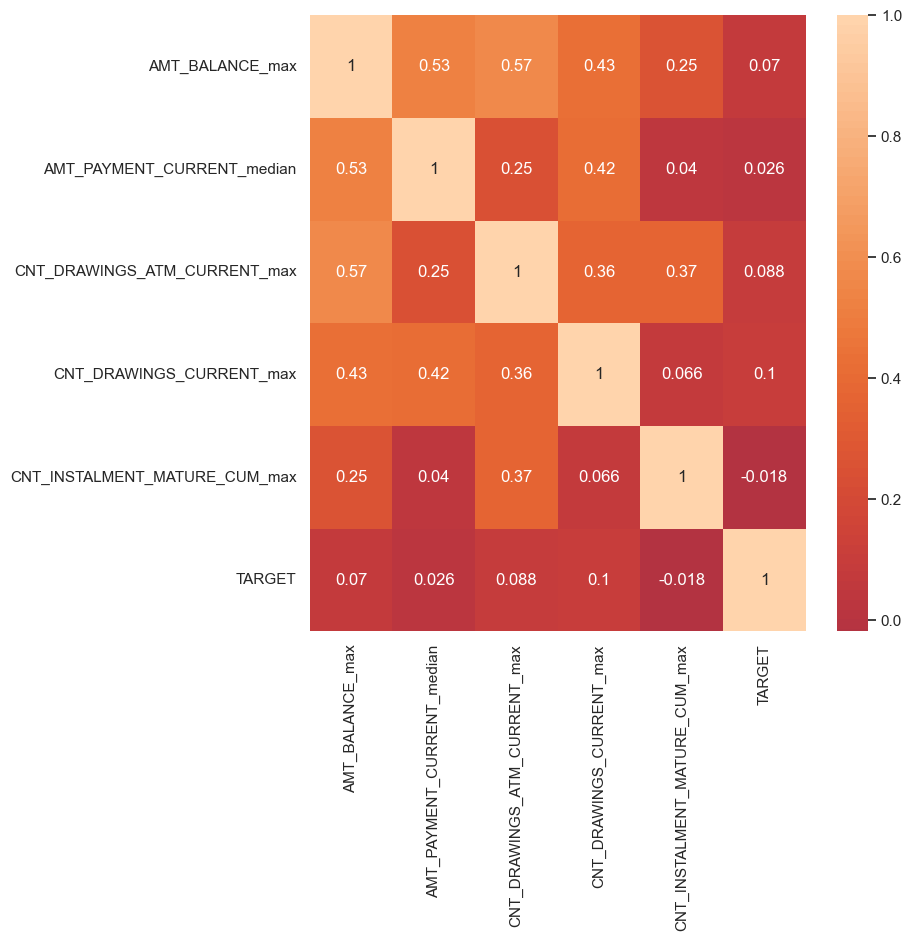

In [82]:
ax=sns.heatmap(clean3.drop(labels=['SK_ID_CURR'], axis=1).corr(), annot=True, center=-1)
ax.get_figure().set_size_inches(w=8, h=8)


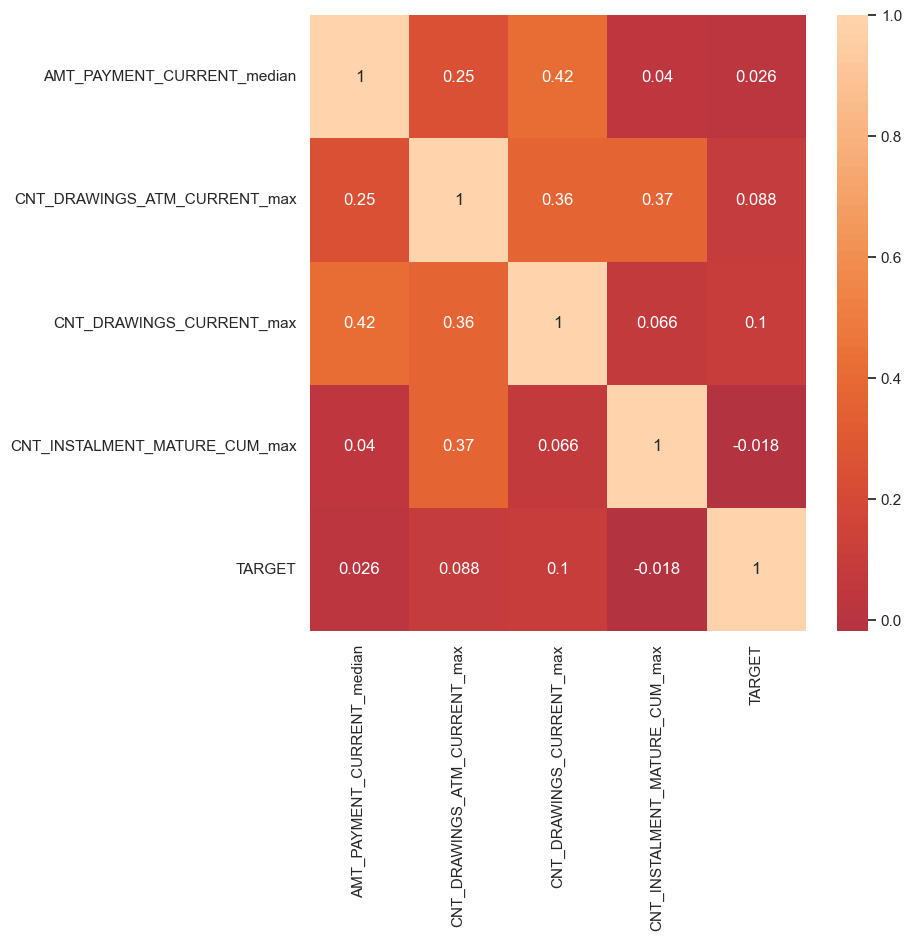

In [83]:
clean3.drop(labels=['AMT_BALANCE_max'], axis=1, inplace=True)
ax=sns.heatmap(clean3.drop(labels='SK_ID_CURR', axis=1).corr(), annot=True, center=-1)
ax.get_figure().set_size_inches(w=8, h=8)


Uncomment This Code for creating the file

In [84]:
# clean3.to_csv('final_clean_card.csv', index=False)

# Previous Applications

freeing memory

In [85]:
del card_data
del clean1
del clean2
del clean3
del outlier_frame
gc.collect()

32898

In [86]:
prev_data=pd.read_csv('initial_clean_prev_app.csv', keep_default_na=False, na_values='')
prev_data.shape

(291057, 11)

In [87]:
prev_data.columns.sort_values()

Index(['AMT_DOWN_PAYMENT_max', 'AMT_DOWN_PAYMENT_max_outlier',
       'PRODUCT_CARD_STREET', 'PRODUCT_CASH_X_SELL_LOW',
       'RATE_DOWN_PAYMENT_max', 'REJECT_HC', 'SELLERPLACE_AREA_max',
       'SELLERPLACE_AREA_max_outlier', 'SK_ID_CURR', 'TARGET', 'YIELD_XNA'],
      dtype='object')

### Dealing with Outliers

In [88]:
'''
contains all outlier marker columns
'''
outlier_frame=prev_data.filter(regex='outlier', axis=1).copy()
outlier_frame['SK_ID_CURR']=prev_data['SK_ID_CURR']
outlier_frame['TARGET']=prev_data['TARGET']
outlier_frame.shape

(291057, 4)

In [108]:
# plot_all_encoded_vs_target(outlier_frame)

In [90]:
outlier_frame.columns

Index(['AMT_DOWN_PAYMENT_max_outlier', 'SELLERPLACE_AREA_max_outlier',
       'SK_ID_CURR', 'TARGET'],
      dtype='object')

In [91]:
clean1=prev_data.loc[(prev_data['AMT_DOWN_PAYMENT_max_outlier']==0)&
              (prev_data['SELLERPLACE_AREA_max_outlier']==0), :].copy()
clean1.drop(labels=outlier_frame.columns.difference(['SK_ID_CURR', 'TARGET']), axis=1, inplace=True)
prev_data.drop(labels=outlier_frame.columns.difference(['SK_ID_CURR', 'TARGET']), axis=1, inplace=True)
clean1.shape

(288903, 9)

### Scaling

In [92]:
clean1.head()

,SK_ID_CURR,TARGET,AMT_DOWN_PAYMENT_max,RATE_DOWN_PAYMENT_max,SELLERPLACE_AREA_max,REJECT_HC,YIELD_XNA,PRODUCT_CARD_STREET,PRODUCT_CASH_X_SELL_LOW
0,100002,1,0.0,0.000000,500,0.0,0.0,0.0,0.0
1,100003,0,6885.0,0.100061,1400,0.0,0.0,0.0,1.0
2,100004,0,4860.0,0.212008,30,0.0,0.0,0.0,0.0
3,100006,0,66987.0,0.217830,8025,0.0,4.0,1.0,2.0
4,100007,0,3676.5,0.218890,1200,0.0,0.0,0.0,0.0


In [93]:
clean1.columns.sort_values()

Index(['AMT_DOWN_PAYMENT_max', 'PRODUCT_CARD_STREET',
       'PRODUCT_CASH_X_SELL_LOW', 'RATE_DOWN_PAYMENT_max', 'REJECT_HC',
       'SELLERPLACE_AREA_max', 'SK_ID_CURR', 'TARGET', 'YIELD_XNA'],
      dtype='object')

In [94]:
ct=ColumnTransformer(transformers=[('numerical', StandardScaler(), ['AMT_DOWN_PAYMENT_max', 'PRODUCT_CARD_STREET',
                                                                    'PRODUCT_CASH_X_SELL_LOW', 'RATE_DOWN_PAYMENT_max', 'REJECT_HC',
                                                                    'SELLERPLACE_AREA_max', 'YIELD_XNA'])],
                     remainder='passthrough')
ct.fit(clean1)
clean2=pd.DataFrame(ct.transform(clean1))
clean2.columns=ct.get_feature_names_out()
clean2.rename(columns=lambda x: x[11:], inplace=True)
clean2.shape

(288903, 9)

### Imputing Null Values

In [95]:
clean2.columns.sort_values()

Index(['AMT_DOWN_PAYMENT_max', 'PRODUCT_CARD_STREET',
       'PRODUCT_CASH_X_SELL_LOW', 'RATE_DOWN_PAYMENT_max', 'REJECT_HC',
       'SELLERPLACE_AREA_max', 'SK_ID_CURR', 'TARGET', 'YIELD_XNA'],
      dtype='object')

#### This Cell will take a long time upto (1 minute)

In [101]:
ct2=ColumnTransformer(transformers=[('numerical', ChunkKNNImputer(factor=10000), ['AMT_DOWN_PAYMENT_max', 'PRODUCT_CARD_STREET',
                                                                                    'PRODUCT_CASH_X_SELL_LOW', 'RATE_DOWN_PAYMENT_max', 'REJECT_HC',
                                                                                    'SELLERPLACE_AREA_max', 'YIELD_XNA'])],
                      remainder='passthrough', n_jobs=-1)


clean3=pd.DataFrame(ct2.fit_transform(clean2))
clean3.columns=ct2.get_feature_names_out()
clean3.rename(columns=lambda x: x[11:], inplace=True)
clean3=clean3.astype(dtype=float)
clean3.shape

(288903, 9)

In [102]:
clean3.columns.sort_values()

Index(['AMT_DOWN_PAYMENT_max', 'PRODUCT_CARD_STREET',
       'PRODUCT_CASH_X_SELL_LOW', 'RATE_DOWN_PAYMENT_max', 'REJECT_HC',
       'SELLERPLACE_AREA_max', 'SK_ID_CURR', 'TARGET', 'YIELD_XNA'],
      dtype='object')

#### further cleaning (dropping based on correlation)

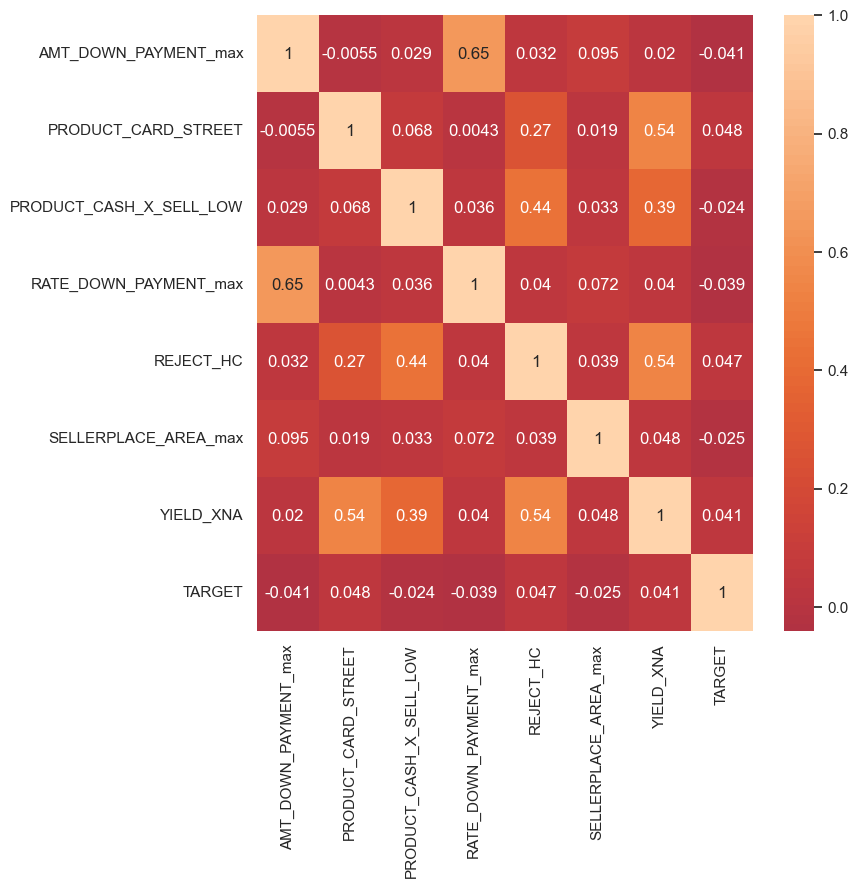

In [103]:
ax=sns.heatmap(clean3.drop(labels=['SK_ID_CURR'], axis=1).corr(), annot=True, center=-1)
ax.get_figure().set_size_inches(w=8, h=8)


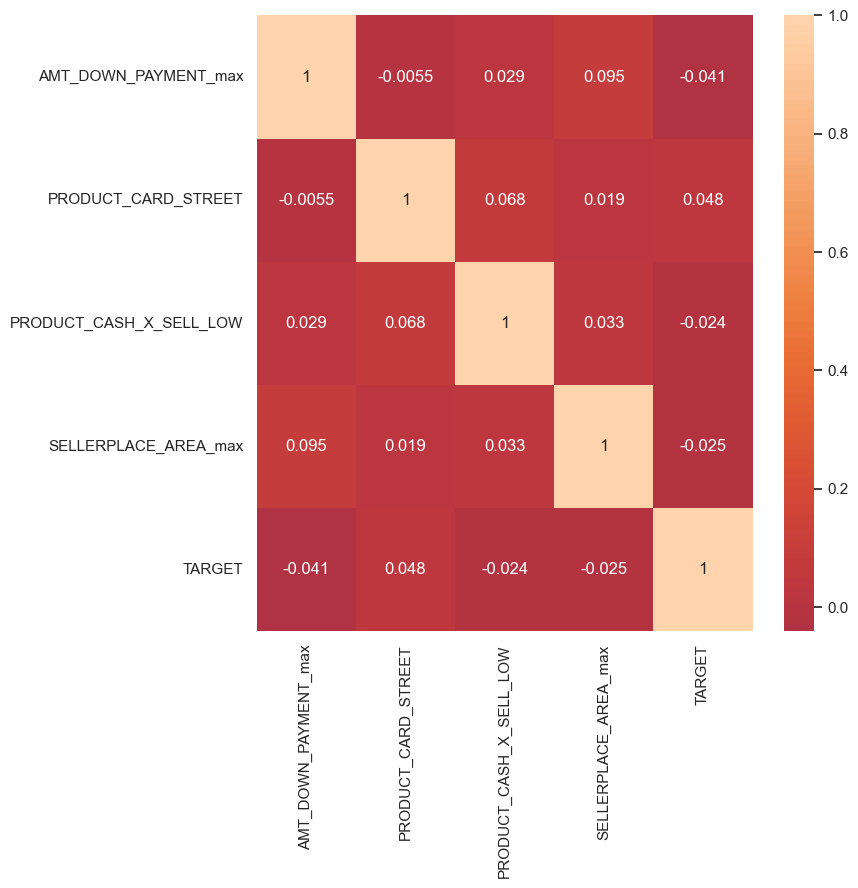

In [106]:
clean3.drop(labels=['RATE_DOWN_PAYMENT_max', 'REJECT_HC', 'YIELD_XNA'], axis=1, inplace=True)
ax=sns.heatmap(clean3.drop(labels='SK_ID_CURR', axis=1).corr(), annot=True, center=-1)
ax.get_figure().set_size_inches(w=8, h=8)


Uncomment This Code for creating the file

In [107]:
clean3.to_csv('final_clean_prev_app.csv', index=False)